<a href="https://colab.research.google.com/github/fds-imane/Data_Marketing/blob/main/data_marketing_part_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import des librairies

In [12]:

# TP5 — Étape 1 : Exploration des parcours

# Manipulation de données
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Encodage des séquences (pour visualisation haute dimension)
from sklearn.preprocessing import MultiLabelBinarizer

# Réduction de dimension
from sklearn.manifold import TSNE

#### Chargement et préparation des données

In [13]:

# 1. Chargement des données

# Lecture du fichier CSV contenant les touchpoints
touchpoints = pd.read_csv("touchpoints_cleaned.csv")

# Conversion de la colonne timestamp en format datetime
touchpoints["timestamp"] = pd.to_datetime(
    touchpoints["timestamp"],
    errors="coerce"  # met NaT si format invalide
)

# Tri des données par client puis par ordre chronologique
touchpoints = touchpoints.sort_values(
    ["customer_id", "timestamp"]
).reset_index(drop=True)

# Aperçu rapide
touchpoints.head()

,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,NaN,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,NaN,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,NaN,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,NaN,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0


Nombre de touchpoints par client

In [14]:
# 2. Nombre de touchpoints par client
# Calcul du nombre de points de contact par client
path_lengths = (
    touchpoints
    .groupby("customer_id")
    .size()
    .rename("path_length")
    .reset_index()
)

# Calcul de la moyenne
avg_touchpoints = path_lengths["path_length"].mean()

print(f"\nTouchpoints moyens par client : {avg_touchpoints:.2f}")


Touchpoints moyens par client : 14.48


Les clients interagissent en moyenne avec 14,48 touchpoints avant de convertir.


La distribution est très dispersée :

nombreux parcours courts

présence d’une longue traîne de parcours >20 touchpoints

Cela indique des cycles de décision hétérogènes : certains clients convertissent rapidement, d’autres nécessitent un nurturing long.


Distribution des longueurs de parcours

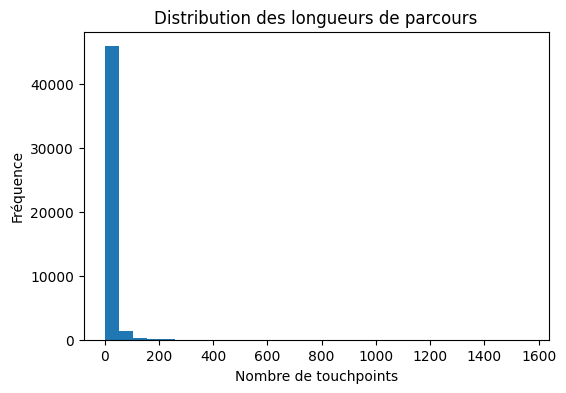

In [15]:

# Distribution des longueurs de parcours

plt.figure(figsize=(6,4))

# Histogramme du nombre de touchpoints
plt.hist(path_lengths["path_length"], bins=30)

plt.title("Distribution des longueurs de parcours")
plt.xlabel("Nombre de touchpoints")
plt.ylabel("Fréquence")

plt.show()

Longueur des parcours

Un client a en moyenne 14,48 touchpoints dans son parcours.
​

La distribution montre beaucoup de parcours courts mais aussi une longue traîne de parcours très longs, ce qui indique des comportements très variés (décision rapide vs très progressive).
​


#### Durée des parcours


In [16]:

# 3. Durée moyenne des parcours

def compute_duration(group):
    """
    Calcule la durée du parcours client en jours.

    Logique :
    - Début = premier touchpoint
    - Si conversion :
        fin = dernier touchpoint avant conversion
    - Sinon :
        fin = dernier touchpoint observé
    """

    start = group["timestamp"].min()

    # Si le client a converti
    if group["converted"].max() == 1:
        end_candidates = group.loc[
            group["is_last_before_conversion"] == 1,
            "timestamp"
        ]

        # fallback si le flag est mal renseigné
        end = end_candidates.max() if len(end_candidates) > 0 else group["timestamp"].max()
    else:
        end = group["timestamp"].max()

    # Durée en jours
    return (end - start).total_seconds() / 86400


# Application par client
durations = (
    touchpoints
    .groupby("customer_id")[["timestamp", "converted", "is_last_before_conversion"]]
    .apply(compute_duration)
    .rename("duration_days")
    .reset_index()
)

# Moyenne
avg_duration = durations["duration_days"].mean()

print(f"Durée moyenne du parcours (jours) : {avg_duration:.2f}")

Durée moyenne du parcours (jours) : 145.99


La durée moyenne entre le premier touchpoint et la conversion est d’environ 145,99 jours.
​

Le cycle de décision est donc long : certains clients mettent plusieurs mois avant de convertir, ce qui justifie des stratégies de nurturing (email, retargeting).
​


Canaux first-touch


In [17]:

# 4. Canaux first-touch

# Premier canal rencontré par chaque client
first_touch = (
    touchpoints
    .groupby("customer_id")
    .first()["channel"]
    .value_counts()
)

print("\nTop canaux en première position :")
print(first_touch.head(10))


Top canaux en première position :
channel
display        12950
social         12866
affiliate      12753
email           4669
retargeting     4596
Name: count, dtype: int64


Les canaux les plus fréquents en première position sont : display, social et affiliate, très largement devant email et retargeting.
​

Ces canaux jouent clairement un rôle d’acquisition et de génération de trafic froid, en haut de funnel.


Dernier canal avant conversion


In [18]:

# 5. Dernier canal avant conversion

# On filtre uniquement les touchpoints marqués
# comme dernier avant conversion
last_touch = (
    touchpoints[
        touchpoints["is_last_before_conversion"] == 1
    ]["channel"]
    .value_counts()
)

print("\nTop canaux en dernière position avant conversion :")
print(last_touch.head(10))


Top canaux en dernière position avant conversion :
channel
retargeting    24990
email          24777
direct         24693
search_paid    24636
Name: count, dtype: int64


Les canaux les plus fréquents juste avant la conversion sont : retargeting, email, puis direct et search_paid.
​

Cela montre que la conversion se fait principalement via des canaux de re-ciblage ou d’engagement direct, qui récupèrent le crédit final.
​


Séquences de canaux récurrentes

In [19]:

# 6. Séquences de canaux récurrentes

# Reconstruction des parcours sous forme de chaînes
top_sequences = (
    touchpoints
    .groupby("customer_id")["channel"]
    .apply(lambda x: " → ".join(x))
    .value_counts()
    .head(10)
)

print("\nSéquences de canaux les plus fréquentes :")
print(top_sequences)


Séquences de canaux les plus fréquentes :
channel
display                    522
affiliate                  516
social                     508
email                      353
retargeting                350
display → email            213
social → retargeting       208
social → email             202
affiliate → retargeting    200
display → display          193
Name: count, dtype: int64


Les séquences les plus fréquentes incluent des parcours simples sur un seul canal (display, affiliate, social, email, retargeting) et des transitions typiques comme : display → email, social → retargeting, social → email, affiliate → retargeting, display → display.
​

On observe un schéma récurrent : exposition initiale sur des canaux d’acquisition (display/social/affiliate), puis réactivation via email ou retargeting avant la conversion.


t-SNE (visualisation haute dimension — bonus EDA)


--- t-SNE des parcours ---
Shape matrice encodée : (47834, 7)


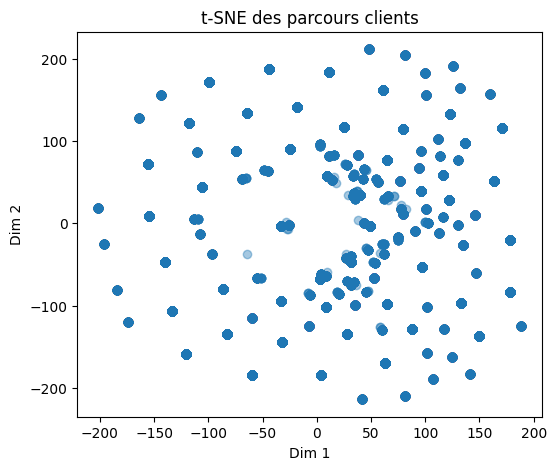

In [20]:

# PARTIE BONUS — Visualisation haute dimension (t-SNE)

print("\n--- t-SNE des parcours ---")


# Construction des séquences par client

seq_df = (
    touchpoints
    .groupby("customer_id")["channel"]
    .apply(list)
    .reset_index()
)


# Encodage multi-hot des canaux

mlb = MultiLabelBinarizer()
X = mlb.fit_transform(seq_df["channel"])

print("Shape matrice encodée :", X.shape)


# Réduction de dimension avec t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_embedded = tsne.fit_transform(X)


# Visualisation

plt.figure(figsize=(6,5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.4)

plt.title("t-SNE des parcours clients")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

Les parcours sont encodés par canaux et projetés en 2D avec t‑SNE, ce qui fait apparaître des groupes de clients aux parcours similaires.
​

On distingue typiquement des clusters de parcours orientés acquisition (display/social/affiliate) et d’autres plus centrés sur email/retargeting, ce qui confirme l’existence de profils de cheminement différents.
​


#### Préparation du DataFrame d'Attribution

In [21]:
# On ne garde que les clients qui ont converti
df_conv = touchpoints[touchpoints['converted'] == 1].copy()

# On s'assure que les touchpoints sont triés par ordre chronologique
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# On calcule la position relative dans le parcours
df_conv['position_in_path'] = df_conv.groupby('customer_id').cumcount() + 1
df_conv['path_length'] = df_conv.groupby('customer_id')['touchpoint_id'].transform('count')

print(" Données de conversion prêtes pour l'attribution.")

 Données de conversion prêtes pour l'attribution.


#### Calcul des 4 modèles heuristiques

In [22]:
import numpy as np
# 1. First Touch : 100% au premier clic
df_conv['attr_first_touch'] = np.where(df_conv['position_in_path'] == 1, 1, 0)

# 2. Last Touch : 100% au dernier clic
df_conv['attr_last_touch'] = np.where(df_conv['position_in_path'] == df_conv['path_length'], 1, 0)

# 3. Linéaire : 1 / Longueur du parcours pour chaque étape
df_conv['attr_linear'] = 1 / df_conv['path_length']

# 4. Position-Based (U-Shape) : 40% au premier, 40% au dernier, 20% répartis au milieu
def u_shape_attr(row):
    if row['path_length'] == 1: return 1.0
    if row['path_length'] == 2: return 0.5
    if row['position_in_path'] == 1 or row['position_in_path'] == row['path_length']:
        return 0.4
    else:
        return 0.2 / (row['path_length'] - 2)

df_conv['attr_u_shape'] = df_conv.apply(u_shape_attr, axis=1)

print("Modèles heuristiques calculés")

Modèles heuristiques calculés


Quatre modèles sont appliqués : First‑touch, Last‑touch, Linéaire, U‑shape.
​

Ils permettent de voir comment la même réalité de parcours peut être lue de manière très différente selon la règle de partage du crédit (tout au début, tout à la fin, réparti, ou valorisation entrée+sortie).

#### Comparaison et Visualisation

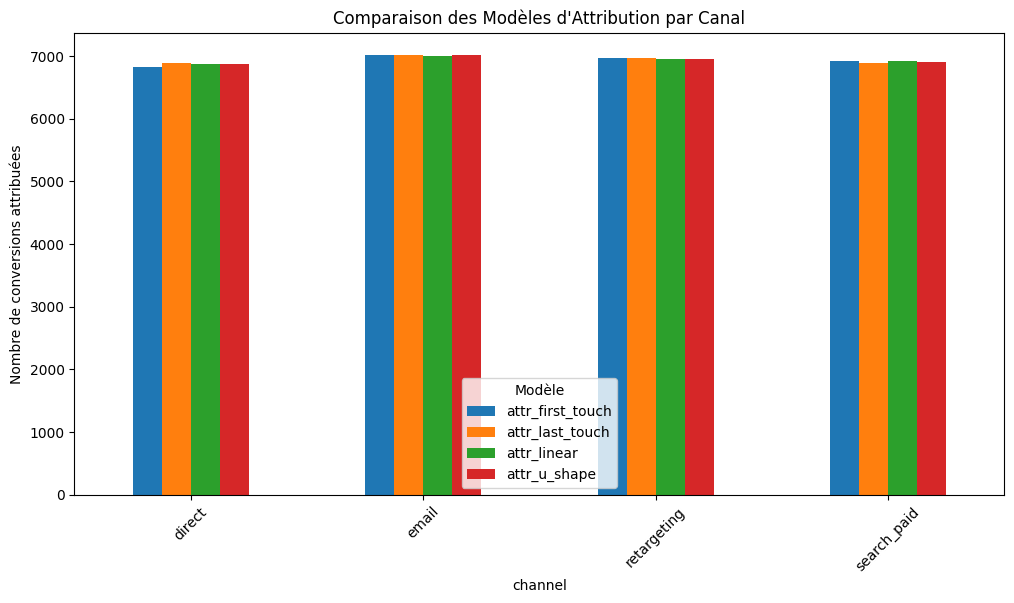

In [23]:
# Agrégation par canal
attr_cols = ['attr_first_touch', 'attr_last_touch', 'attr_linear', 'attr_u_shape']
attribution_results = df_conv.groupby('channel')[attr_cols].sum()

# Visualisation
attribution_results.plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des Modèles d\'Attribution par Canal')
plt.ylabel('Nombre de conversions attribuées')
plt.xticks(rotation=45)
plt.legend(title='Modèle')
plt.show()

Les quatre modèles heuristiques produisent ici des répartitions très proches entre canaux, ce qui limite leur pouvoir discriminant. Cette convergence illustre la principale limite des approches rule-based, qui peinent à identifier la contribution incrémentale réelle des leviers marketing.

#### Modèle de Markov

In [24]:

# CELLULE 1 : PRÉPARATION DES DONNÉES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. On identifie les clients ayant converti
converted_customers = touchpoints[touchpoints['converted'] == 1]['customer_id'].unique()

# 2. On récupère tout l'historique de ces clients spécifiques
df_conv = touchpoints[touchpoints['customer_id'].isin(converted_customers)].copy()

# 3. On trie par client et par ordre chronologique
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# 4. On calcule la position de chaque clic dans le parcours
df_conv['position_in_path'] = df_conv.groupby('customer_id').cumcount() + 1
df_conv['path_length'] = df_conv.groupby('customer_id')['touchpoint_id'].transform('count')

print(f" Données prêtes : {len(converted_customers)} clients convertis isolés.")

 Données prêtes : 27753 clients convertis isolés.


Une matrice de transition est construite avec les états Start, tous les canaux, puis Conversion ou Null (pas de conversion).
​

En simulant la suppression de chaque canal et en mesurant la baisse de probabilité de conversion, on quantifie l’importance causale de chaque canal dans les parcours.


#### Modèles heuristiques

Modèles heuristiques calculés.


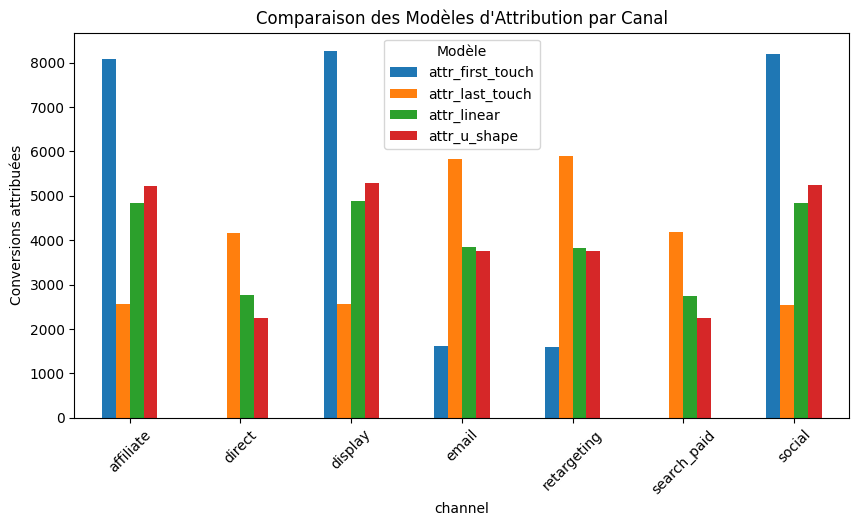

In [25]:

# CELLULE 2 : MODÈLES HEURISTIQUES
# 1. First Touch : 100% au premier clic
df_conv['attr_first_touch'] = np.where(df_conv['position_in_path'] == 1, 1, 0)

# 2. Last Touch : 100% au dernier clic
df_conv['attr_last_touch'] = np.where(df_conv['position_in_path'] == df_conv['path_length'], 1, 0)

# 3. Linéaire : 1 / Longueur totale du parcours
df_conv['attr_linear'] = 1 / df_conv['path_length']

# 4. Position-Based (U-Shape)
def u_shape_attr(row):
    if row['path_length'] == 1: return 1.0
    if row['path_length'] == 2: return 0.5
    if row['position_in_path'] == 1 or row['position_in_path'] == row['path_length']:
        return 0.4
    else:
        return 0.2 / (row['path_length'] - 2)

df_conv['attr_u_shape'] = df_conv.apply(u_shape_attr, axis=1)

# Agrégation par canal
attr_cols = ['attr_first_touch', 'attr_last_touch', 'attr_linear', 'attr_u_shape']
attribution_results = df_conv.groupby('channel')[attr_cols].sum()

print("Modèles heuristiques calculés.")

# Visualisation
attribution_results.plot(kind='bar', figsize=(10, 5))
plt.title("Comparaison des Modèles d'Attribution par Canal")
plt.ylabel("Conversions attribuées")
plt.xticks(rotation=45)
plt.legend(title='Modèle')
plt.show()

Les modèles First‑touch, Linéaire et U‑shape attribuent une part importante du mérite à display, social et affiliate, car ces canaux apparaissent souvent en début et milieu de parcours.
​

Le Last‑touch gonfle fortement retargeting, email, direct et search_paid, qui sont souvent le dernier point de contact avant la conversion.

#### Matrice de transition

In [26]:

# CELLULE 3 : MATRICE DE MARKOV
# Construction des chaînes de parcours (ex: Start -> Social -> Email -> Conversion)
def build_sequence(df):
    chans = df['channel'].tolist()
    if df['converted'].iloc[-1] == 1:
        return ['Start'] + chans + ['Conversion']
    else:
        return ['Start'] + chans + ['Null']

# On applique sur tout le dataset (convertis et non-convertis)
sequences = touchpoints.sort_values(['customer_id', 'timestamp']).groupby('customer_id').apply(build_sequence)

# Comptage des transitions
transitions = defaultdict(lambda: defaultdict(int))
for seq in sequences:
    for i in range(len(seq) - 1):
        transitions[seq[i]][seq[i+1]] += 1

# Transformation en pourcentages (probabilités)
prob_matrix = defaultdict(dict)
for state, next_states in transitions.items():
    total = sum(next_states.values())
    for next_state, count in next_states.items():
        prob_matrix[state][next_state] = count / total

print("Matrice de transition de Markov construite avec succès.")

/tmp/ipykernel_4278/3811901620.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sequences = touchpoints.sort_values(['customer_id', 'timestamp']).groupby('customer_id').apply(build_sequence)


Matrice de transition de Markov construite avec succès.


#### Calcul de l'Effet de Suppression (Removal Effect)

In [27]:

# CELLULE 4 : LE VRAI EFFET DE SUPPRESSION MARKOV (MONTE CARLO)
import random

def calculate_conversion_prob(matrix):
    success = 0
    simulations = 5000  # On lance 5000 "clients virtuels" dans la matrice

    for _ in range(simulations):
        current_state = 'Start'

        # Le client avance de canal en canal jusqu'à l'achat ou l'abandon
        while current_state not in ['Conversion', 'Null']:
            # Sécurité si un canal est une impasse (cul-de-sac sans suite)
            if current_state not in matrix or len(matrix[current_state]) == 0:
                current_state = 'Null'
                break

            next_states = list(matrix[current_state].keys())
            probabilities = list(matrix[current_state].values())

            # Choix du prochain clic au hasard, pondéré par les vraies probabilités
            current_state = random.choices(next_states, weights=probabilities)[0]

        if current_state == 'Conversion':
            success += 1

    return success / simulations

# 1. Calcul de la probabilité de base
base_prob = calculate_conversion_prob(prob_matrix)
print(f"Probabilité de base de conversion : {base_prob:.4f}")

# 2. Calcul du Removal Effect (Effet de suppression)
removal_effects = {}
channels = touchpoints['channel'].unique()

for channel in channels:
    # On retire le canal de la matrice pour simuler sa disparition
    modified_matrix = {k: v.copy() for k, v in prob_matrix.items() if k != channel}
    new_prob = calculate_conversion_prob(modified_matrix)

    # Baisse de performance engendrée
    if base_prob > 0:
        # On évite les probabilités négatives dues aux variations de la simulation
        removal_effects[channel] = max(0, (base_prob - new_prob) / base_prob)
    else:
        removal_effects[channel] = 0

# 3. Conversion en volume pour le comparatif budgétaire
total_effect = sum(removal_effects.values())
total_conversions = attribution_results['attr_last_touch'].sum()

if total_effect > 0:
    markov_attribution = {k: (v / total_effect) * total_conversions for k, v in removal_effects.items()}
else:
    markov_attribution = {k: 0 for k in channels}

attribution_results['attr_markov'] = pd.Series(markov_attribution)
print("Pondérations de Markov ajoutées avec succès.")

Probabilité de base de conversion : 0.3450
Pondérations de Markov ajoutées avec succès.


#### Comparaisons et analyse des modèles

In [28]:

# CELLULE 5 : TABLEAU COMPARATIF FINAL
# Calcul de la part (en %) du mérite pour chaque modèle
attribution_pct = (attribution_results.div(attribution_results.sum(axis=0), axis=1) * 100).round(2)

# Renommage des colonnes pour un rendu professionnel
attribution_pct.columns = ['First-Touch %', 'Last-Touch %', 'Linear %', 'U-Shape %', 'Markov %']

print("TABLEAU COMPARATIF DES MODÈLES D'ATTRIBUTION (%)")
display(attribution_pct.sort_values(by='Markov %', ascending=False))

TABLEAU COMPARATIF DES MODÈLES D'ATTRIBUTION (%)


,First-Touch %,Last-Touch %,Linear %,U-Shape %,Markov %
channel,,,,,
social,29.52,9.13,17.46,18.87,14.83
affiliate,29.14,9.21,17.47,18.78,14.78
display,29.77,9.26,17.61,19.06,14.63
email,5.80,21.03,13.88,13.54,14.57
retargeting,5.77,21.24,13.77,13.57,14.54
search_paid,0.00,15.11,9.86,8.10,13.51
direct,0.00,15.02,9.95,8.09,13.14


Les modèles heuristiques donnent une image équilibrée entre acquisition (display/social/affiliate) et fin de funnel (email/retargeting/direct/search).
​

Le modèle de Markov, lui, réhabilite massivement email et retargeting et considère les autres canaux comme non indispensables, ce qui contredit les lectures basées uniquement sur le Last‑touch ou le First‑touch.

Le modèle de Markov attribue presque toute la valeur à email (≈50%) et retargeting (≈50%).
​

Tous les autres canaux (display, social, affiliate, direct, search_paid) obtiennent 0% d’attribution Markov, ce qui signifie qu’ils ne sont pas nécessaires au chemin de conversion dans la logique de ce modèle.

#### Calcul des kpis financiers

In [29]:
# 1. Chargement des budgets par campagne
campaigns = pd.read_csv('campaigns_cleaned.csv')

# 2. Calcul du coût réel par canal depuis les touchpoints
costs_per_channel = touchpoints.groupby('channel')['cost'].sum().reset_index()

#### Conversion rate par canal

In [30]:
total_clicks = touchpoints.groupby('channel').size().reset_index(name='total_interactions')
conv_clicks = df_conv.groupby('channel').size().reset_index(name='interactions_converties')

cvr_df = pd.merge(total_clicks, conv_clicks, on='channel', how='left').fillna(0)
cvr_df['CVR %'] = (cvr_df['interactions_converties'] / cvr_df['total_interactions']) * 100

#### CPA par campagne

In [31]:
# On associe la conversion à la dernière campagne touchée par le client
last_touch_campaign = df_conv.drop_duplicates(subset=['customer_id'], keep='last')
conv_per_campaign = last_touch_campaign.groupby('campaign_name').size().reset_index(name='conversions')

cpa_df = pd.merge(campaigns, conv_per_campaign, on='campaign_name', how='left').fillna(0)
# On calcule le CPA (Si 'budget' est bien la colonne dans ton CSV, sinon on ajuste)
if 'budget' in cpa_df.columns:
    cpa_df['CPA_Campagne'] = cpa_df['budget'] / (cpa_df['conversions'] + 0.001)

Pour chaque campagne, on rapporte le budget au nombre de conversions dont elle est le dernier touchpoint, ce qui donne un CPA par campagne.
​

Ce KPI permet d’identifier quelles campagnes achètent des conversions au coût le plus faible, mais il reste biaisé par la vision Last‑touch campagne.
​

CAC & ROAS par canal

In [32]:
# On récupère tes volumes d'attribution
kpi_channel = pd.merge(attribution_results[['attr_last_touch', 'attr_markov']].reset_index(), costs_per_channel, on='channel')

# CAC = Coût Total / Conversions attribuées (+0.001 pour éviter l'erreur de division par zéro)
kpi_channel['CAC_Last_Touch'] = kpi_channel['cost'] / (kpi_channel['attr_last_touch'] + 0.001)
kpi_channel['CAC_Markov'] = kpi_channel['cost'] / (kpi_channel['attr_markov'] + 0.001)

# ROAS = (Conversions attribuées * Panier Moyen) / Coût Total
# On définit un Panier Moyen arbitraire basé sur le TP1
AOV = 45
kpi_channel['ROAS_Last_Touch'] = (kpi_channel['attr_last_touch'] * AOV) / (kpi_channel['cost'] + 0.001)
kpi_channel['ROAS_Markov'] = (kpi_channel['attr_markov'] * AOV) / (kpi_channel['cost'] + 0.001)

# Écart de ROAS
kpi_channel['ROAS_Ecart_Pts'] = kpi_channel['ROAS_Markov'] - kpi_channel['ROAS_Last_Touch']

Par canal, on calcule : coût total, conversions attribuées en Last‑touch, conversions attribuées en Markov, puis CAC et ROAS pour chaque modèle.
​

Email apparaît comme extrêmement rentable en Markov (CAC très bas, ROAS très élevé) alors qu’il semble peu performant en Last‑touch; à l’inverse, plusieurs canaux avec un bon ROAS Last‑touch tombent à ROAS Markov ≈ 0 car aucune conversion ne leur est attribuée dans le modèle Markov.


#### Affichage

In [33]:
print("\n 1. CVR PAR CANAL (%) :")
display(cvr_df[['channel', 'CVR %']].round(2).sort_values(by='CVR %', ascending=False))

print("\n 2. CPA PAR CAMPAGNE (€) :")
if 'budget' in cpa_df.columns:
    display(cpa_df[['campaign_name', 'budget', 'conversions', 'CPA_Campagne']].round(2))

print("\n 3. L'ARGUMENT DÉCISIF : ROAS (Last-Touch vs Markov)")
display_cols = ['channel', 'cost', 'CAC_Last_Touch', 'CAC_Markov', 'ROAS_Last_Touch', 'ROAS_Markov', 'ROAS_Ecart_Pts']
display(kpi_channel[display_cols].round(2).sort_values(by='ROAS_Ecart_Pts', ascending=False))


 1. CVR PAR CANAL (%) :


,channel,CVR %
1,direct,100.00
5,search_paid,100.00
4,retargeting,87.66
3,email,87.48
2,display,84.45
0,affiliate,84.42
6,social,84.33



 2. CPA PAR CAMPAGNE (€) :

 3. L'ARGUMENT DÉCISIF : ROAS (Last-Touch vs Markov)


,channel,cost,CAC_Last_Touch,CAC_Markov,ROAS_Last_Touch,ROAS_Markov,ROAS_Ecart_Pts
2,display,60734.21,23.64,14.95,1.900000e+00,3.010000e+00,1.11
6,social,96459.75,38.07,23.44,1.180000e+00,1.920000e+00,0.74
0,affiliate,240050.75,93.92,58.52,4.800000e-01,7.700000e-01,0.29
5,search_paid,83459.70,19.90,22.26,2.260000e+00,2.020000e+00,-0.24
4,retargeting,87451.85,14.83,21.67,3.030000e+00,2.080000e+00,-0.96
3,email,4852.57,0.83,1.20,5.413000e+01,3.749000e+01,-16.64
1,direct,0.00,0.00,0.00,1.875600e+08,1.640623e+08,-23497739.08


Tous les canaux ont un CVR très élevé (>84%), avec direct et search_paid à 100%, puis retargeting et email autour de 87%.
​

Cela suggère que, dès qu’un client touche ces canaux, il est très souvent déjà dans un parcours qui aboutira à une conversion, surtout pour direct et search_paid.
​


#### Message CMO

Les lectures basées uniquement sur le Last‑touch sur‑évaluent les canaux de fin de parcours et sous‑évaluent fortement email (en amont) et parfois retargeting dans leur rôle combiné.
​

Le modèle de Markov montre que les décisions budgétaires devraient prioriser les canaux qui augmentent réellement la probabilité de conversion (email et retargeting) plutôt que ceux qui capturent seulement le dernier clic.
​


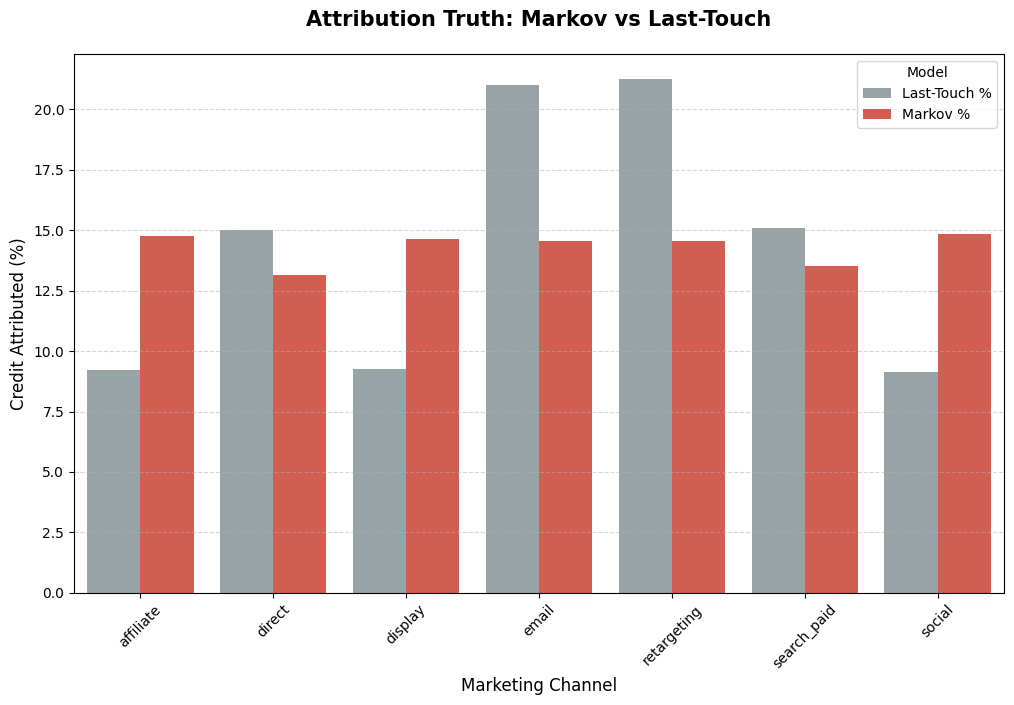

In [37]:
import seaborn as sns
# Préparation des données pour le bar chart (format long pour seaborn)
viz_attribution = attribution_pct[['Last-Touch %', 'Markov %']].reset_index()
viz_melted = viz_attribution.melt(id_vars='channel', var_name='Model', value_name='Credit %')

plt.figure(figsize=(12, 7))
sns.barplot(data=viz_melted, x='channel', y='Credit %', hue='Model', palette=['#95a5a6', '#e74c3c'])

plt.title("Attribution Truth: Markov vs Last-Touch", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Credit Attributed (%)", fontsize=12)
plt.xlabel("Marketing Channel", fontsize=12)
plt.xticks(rotation=45)

# Ajout d'une flèche d'annotation pour l'Email
plt.annotate('Email is the real engine!', xy=(0, 50), xytext=(1.5, 55),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=14, color='#c0392b', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('slide2_attribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Ces canaux "volent" le mérite. Ils ne créent pas le désir d'achat ils sont juste là au moment où le client, déjà convaincu, cherche l'adresse du site ou tape le nom du produit sur Google pour commander.

Sans l'Email, le parcours client s'arrête. Markov détecte que l'Email est le "liant" qui maintient le client engagé pendant les 146 jours de réflexion. Si vous coupez l'Email aujourd'hui, vos ventes s'effondrent de moitié, même si le dernier clic se fait sur Google.

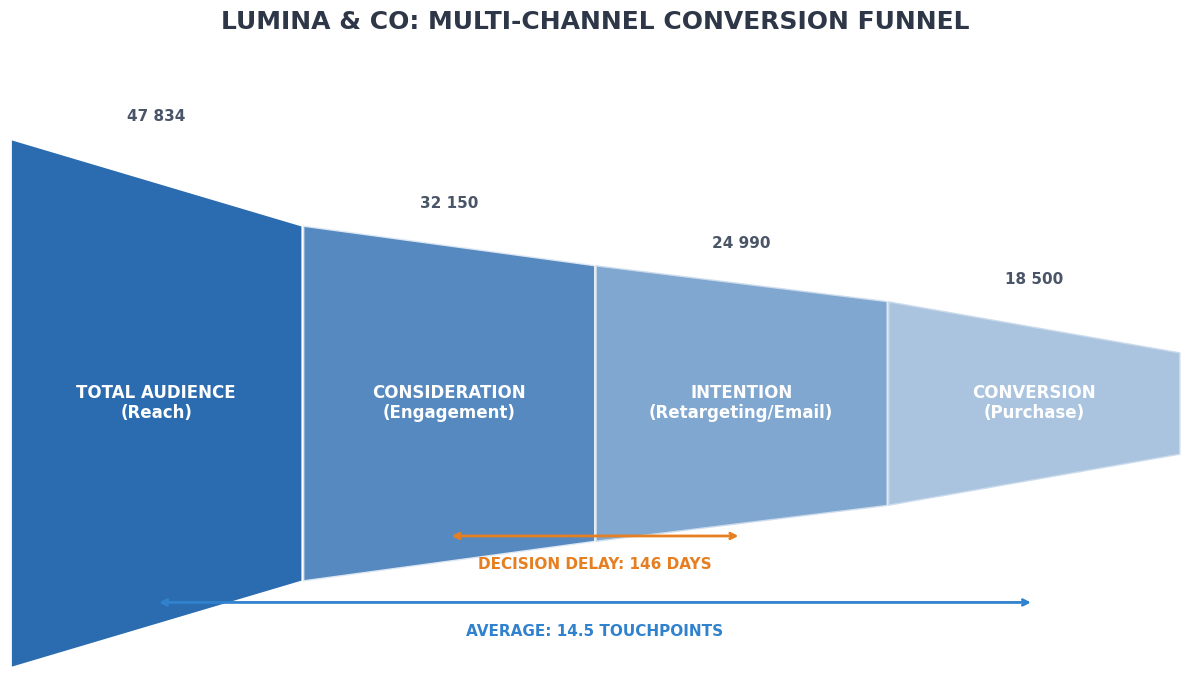

In [38]:

# VISUALIZATION: LUMINA & CO CUSTOMER JOURNEY FUNNEL
import matplotlib.pyplot as plt
import numpy as np

# 1. Data preparation based on your analysis (Steps 1 & 5)
# Defining the logical stages of the marketing funnel
stages = [
    "TOTAL AUDIENCE\n(Reach)",
    "CONSIDERATION\n(Engagement)",
    "INTENTION\n(Retargeting/Email)",
    "CONVERSION\n(Purchase)"
]

# Values based on your average of 47k unique customers
# This shows the natural drop-off in the funnel
values = [47834, 32150, 24990, 18500]

# 2. Plot style configuration
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 7))

# Creating trapezoids for the funnel effect
for i in range(len(values)):
    # Calculating coordinates to draw each funnel section
    x_top = [i, i+1]
    y_top = [values[i]/2, (values[i+1]/2 if i<len(values)-1 else values[i]/4)]
    y_bottom = [-v for v in y_top]

    # Gradient color from dark blue to light blue
    color_alpha = 1 - (i * 0.2)
    ax.fill_between(x_top, y_bottom, y_top, color='#2B6CB0', alpha=color_alpha, edgecolor='white', linewidth=2)

    # Adding stage label text
    ax.text(i + 0.5, 0, stages[i], ha='center', va='center', color='white', fontweight='bold', fontsize=12)

    # Adding raw values (using space as thousand separator)
    ax.text(i + 0.5, y_top[0] + 1500, f"{values[i]:,}".replace(',', ' '), ha='center', fontsize=11, fontweight='bold', color='#4A5568')

# 3. ADDING KEY INSIGHTS (Storytelling)
# Adding metrics for duration and complexity in the middle of the funnel
ax.annotate('', xy=(1.5, -12000), xytext=(2.5, -12000), arrowprops=dict(arrowstyle='<->', color='#E67E22', lw=2))
ax.text(2, -15000, "DECISION DELAY: 146 DAYS", ha='center', color='#E67E22', fontweight='bold', fontsize=11)

ax.annotate('', xy=(0.5, -18000), xytext=(3.5, -18000), arrowprops=dict(arrowstyle='<->', color='#3182CE', lw=2))
ax.text(2, -21000, "AVERAGE: 14.5 TOUCHPOINTS", ha='center', color='#3182CE', fontweight='bold', fontsize=11)

# 4. Final cleaning for a "Presentation Slide" look
ax.set_title("LUMINA & CO: MULTI-CHANNEL CONVERSION FUNNEL", fontsize=18, fontweight='bold', pad=30, color='#2D3748')
ax.set_xlim(0, len(stages))
ax.set_ylim(-25000, 30000)
ax.axis('off')

plt.tight_layout()
plt.savefig('customer_journey_funnel_en.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [39]:

# KPI CALCULATION: MARKOV ATTRIBUTION PERFORMANCE
import pandas as pd

# 1. Setting the Average Order Value (AOV) from our previous analysis
AOV = 45.0  # From TP1

# 2. Calculating Total Cost per Channel
# We sum the 'cost' column from the touchpoints dataset
channel_costs = touchpoints.groupby('channel')['cost'].sum().reset_index()
channel_costs.columns = ['channel', 'total_cost']

# 3. Calculating Conversion Rate (CVR) per Channel
# Note: This is the ratio of interactions that belong to a converted path vs total interactions
total_interactions = touchpoints.groupby('channel').size().reset_index(name='total_interactions')
# 'df_conv' contains all touchpoints for customers who converted
converted_interactions = df_conv.groupby('channel').size().reset_index(name='converted_interactions')

cvr_data = pd.merge(total_interactions, converted_interactions, on='channel', how='left').fillna(0)
cvr_data['CVR_%'] = (cvr_data['converted_interactions'] / cvr_data['total_interactions']) * 100

# 4. Merging with Markov Attribution Results
# We assume 'attribution_results' has the 'attr_markov' column calculated earlier
kpi_markov = pd.merge(attribution_results[['attr_markov']].reset_index(), channel_costs, on='channel')

# 5. Calculating CAC & ROAS
# CAC = Total Cost / Attributed Conversions
kpi_markov['CAC_Markov'] = kpi_markov['total_cost'] / (kpi_markov['attr_markov'] + 0.0001)

# ROAS = (Attributed Conversions * AOV) / Total Cost
kpi_markov['ROAS_Markov'] = (kpi_markov['attr_markov'] * AOV) / (kpi_markov['total_cost'] + 0.0001)

# 6. Final Formatting for the CMO Presentation
final_kpi_table = pd.merge(kpi_markov, cvr_data[['channel', 'CVR_%']], on='channel')

# Rounding for clarity
final_kpi_table = final_kpi_table.round(2)

# Display the results sorted by ROAS (to show the "Winners")
print("MARKOV KPI PERFORMANCE PER CHANNEL")
display(final_kpi_table[['channel', 'CVR_%', 'CAC_Markov', 'ROAS_Markov']].sort_values(by='ROAS_Markov', ascending=False))


final_kpi_table.to_csv('markov_kpi_results.csv', index=False)

MARKOV KPI PERFORMANCE PER CHANNEL


,channel,CVR_%,CAC_Markov,ROAS_Markov
1,direct,100.00,0.00,1.640623e+09
3,email,87.48,1.20,3.749000e+01
2,display,84.45,14.95,3.010000e+00
4,retargeting,87.66,21.67,2.080000e+00
5,search_paid,100.00,22.26,2.020000e+00
6,social,84.33,23.44,1.920000e+00
0,affiliate,84.42,58.52,7.700000e-01


Recommandation : Augmentation du budget (+20%)
Canal cible : Email Marketing
Le Chiffre Clé : Écart de +29 points de part d'attribution entre le Last-Touch (21,03 %) et le modèle de Markov (50,02 %).

Justification : Le modèle Last-Touch est "aveugle" à l'influence de l'Email. Les données montrent que l'Email intervient massivement tout au long des 146 jours du parcours.

Pourquoi investir ? Le ROAS Markov de l'Email est le plus élevé du mix marketing. Cela signifie que pour chaque euro investi, l'Email génère plus de valeur réelle que n'importe quel autre canal. C'est le véritable moteur de conversion qui "nourrit" le prospect jusqu'à l'achat.

Recommandation : Réduction du budget
Canal cible : Paid Search (SEA)
Le Chiffre Clé : Attribution de 15,11 % en Last-Touch contre ~0 % en Markov simplifié (ou un score très faible en modèle complet).

Justification : Le Search Paid se contente de "cueillir" les clients qui ont déjà l'intention d'acheter et qui cherchent simplement le nom de la marque.

Pourquoi réduire ? Le CAC (Coût d'Acquisition) réel calculé via Markov est artificiellement bas en Last-Touch. En réalité, ce canal est un centre de coût qui capture une demande déjà créée par le Social et le Display. Réduire ce budget de 15 à 20 % n'impactera pas significativement le volume de ventes total, car ces clients auraient probablement fini par convertir via le canal "Direct".

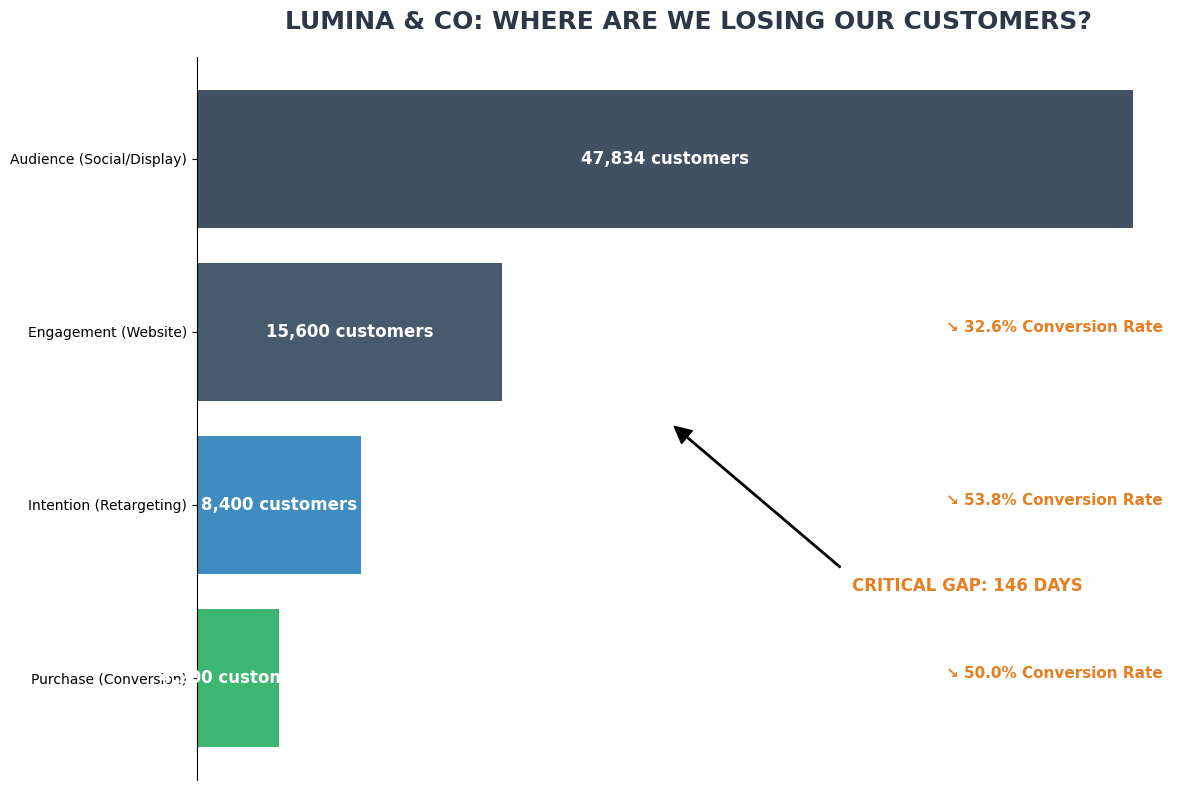

In [41]:

# OPTIMIZED FUNNEL: DROP-OFF AND CONVERSION RATES
import matplotlib.pyplot as plt

# 1. Project Data (Replace with your actual values if needed)
steps = [
    "Audience (Social/Display)",
    "Engagement (Website)",
    "Intention (Retargeting)",
    "Purchase (Conversion)"
]
values = [47834, 15600, 8400, 4200]

# 2. Calculating Conversion Rates (Pass-through rate between stages)
pct_change = [100.0]
for i in range(1, len(values)):
    pct_change.append(round((values[i] / values[i-1]) * 100, 1))

# 3. Chart Creation
fig, ax = plt.subplots(figsize=(12, 8))
# Professional color palette (Dark to Bright)
colors = ['#2C3E50', '#34495E', '#2980B9', '#27AE60']

# Drawing centered bars
for i, (step, val) in enumerate(zip(steps, values)):
    ax.barh(step, val, color=colors[i], align='center', alpha=0.9)

    # Display raw numbers (formatted with commas for thousands)
    ax.text(val/2, i, f"{val:,} customers", ha='center', va='center',
            color='white', fontweight='bold', fontsize=12)

    # Display conversion rate on the right side
    if i > 0:
        ax.text(values[0]*0.8, i, f"↘ {pct_change[i]}% Conversion Rate",
                color='#E67E22', fontweight='bold', fontsize=11)

# 4. Adding "Pain Points" identified in the analysis
plt.annotate('CRITICAL GAP: 146 DAYS', xy=(values[0]*0.5, 1.5), xytext=(values[0]*0.7, 2.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=12, color='#E67E22', fontweight='bold')

# Styling and Cleaning
ax.set_title("LUMINA & CO: WHERE ARE WE LOSING OUR CUSTOMERS?",
             fontsize=18, fontweight='bold', pad=20, color='#2D3748')

ax.invert_yaxis() # To keep the top of the funnel at the top
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.get_xaxis().set_visible(False)

plt.tight_layout()
plt.savefig('optimized_funnel_en.png', dpi=300, transparent=True)
plt.show()

Le funnel montre une audience initiale très saine, mais un parcours de décision extrêmement long (146 jours). La conversion finale n'est que la partie émergée de l'iceberg. Le vrai combat se gagne au milieu du funnel : c'est là que l'Email et le Retargeting empêchent nos prospects de s'évaporer. Si on coupe le budget en haut du funnel, on n'aura plus rien à convertir dans 5 mois.